### EX: Anomaly Detection

In this exercise, we will build an Autoencoder to detect network intrusions.

* **Generate Data:** Simulate 20-dimensional network traffic logs. We will create a massive dataset of "Normal" traffic, and a small dataset of "Malicious" traffic.

* **Build Autoencoder:** Create a network that compresses 20 inputs down to a 4-neuron bottleneck, then decompresses back to 20.

* **Train:** Train the model *only* on Normal traffic.

* **Predict & Evaluate:** Pass both Normal and Malicious traffic through the model. Calculate the Mean Squared Error of the reconstruction and plot the divergence.

In [ ]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas tensorflow

Training Autoencoder on normal baseline traffic...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


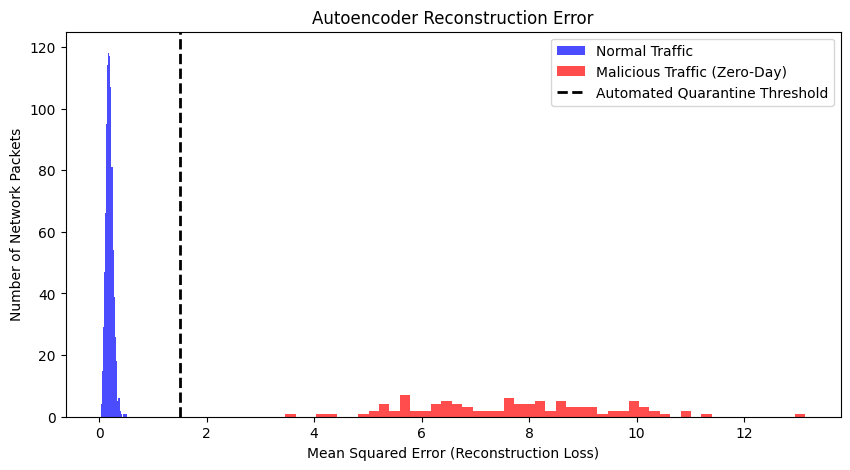

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import mean_squared_error

# 1. Generate Network Traffic Data (20 simulated packet features)
np.random.seed(42)
# Normal traffic: Standard variance
X_normal = np.random.normal(0, 0.5, (2000, 20)) 
# Malicious traffic: Different signature/variance (The Zero-Day Attack)
X_malicious = np.random.normal(3, 1.5, (100, 20)) 

# 2. Build the Autoencoder Architecture
input_layer = Input(shape=(20,))
# Encoder (Compresses 20 -> 10 -> 4)
encoded = Dense(10, activation='relu')(input_layer)
bottleneck = Dense(4, activation='relu')(encoded) # The Latent Space

# Decoder (Expands 4 -> 10 -> 20)
decoded = Dense(10, activation='relu')(bottleneck)
output_layer = Dense(20, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# 3. Train ONLY on Normal Traffic
print("Training Autoencoder on normal baseline traffic...")
autoencoder.fit(X_normal, X_normal, epochs=50, batch_size=32, validation_split=0.1, verbose=0)

# 4. Predict (Reconstruct) both datasets
reconstructed_normal = autoencoder.predict(X_normal)
reconstructed_malicious = autoencoder.predict(X_malicious)

# 5. Calculate Reconstruction Error (MSE) per sample
mse_normal = np.mean(np.square(X_normal - reconstructed_normal), axis=1)
mse_malicious = np.mean(np.square(X_malicious - reconstructed_malicious), axis=1)

# 6. Plot the Anomaly Threshold
plt.figure(figsize=(10, 5))
plt.hist(mse_normal, bins=50, alpha=0.7, color='blue', label='Normal Traffic')
plt.hist(mse_malicious, bins=50, alpha=0.7, color='red', label='Malicious Traffic (Zero-Day)')
plt.axvline(x=1.5, color='black', linestyle='--', linewidth=2, label='Automated Quarantine Threshold')
plt.title('Autoencoder Reconstruction Error')
plt.xlabel('Mean Squared Error (Reconstruction Loss)')
plt.ylabel('Number of Network Packets')
plt.legend()
plt.show()

### Interpreting the Results

Look at the histogram. The Autoencoder learned the underlying mathematical "grammar" of the blue Normal traffic perfectly, meaning it can compress and reconstruct those packets with near-zero error.

However, when the red Malicious traffic hit the network, the Autoencoder's bottleneck completely choked. It had never learned the features necessary to compress that specific type of data, resulting in massive reconstruction errors (MSE > 5.0). By setting an automated threshold at 1.5, the cyber warfare operator has created a system capable of catching entirely new, unclassified malware without ever having trained on it.
